# 📋 INSTRUCTOR NOTEBOOK — Multilayer Perceptrons for Time-Series Forecasting

**Module 0 · Lesson 9 of 13 · Instructor edition**  
**Estimated class time:** 80–95 minutes  
**Source sequence:** Original Day 3  

**Prerequisite:** Lessons 7–8  

> **Do not distribute to students.** This edition contains solutions, teaching notes, and model answers.

## Learning objectives

By the end of this lesson, you should be able to:

- Scale time-series features without leaking test information.
- Implement and train an MLP forecaster in PyTorch.
- Evaluate neural forecasts on the original target scale.

## Setup for this lesson

This cell recreates the data and completed prerequisites from earlier lessons, so this notebook can be run in a fresh kernel.

In [ ]:
# Shared forecasting setup from the preceding lesson
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.ar_model import AutoReg
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])
df.columns = ['Date', 'Passengers']
df['Log_Passengers'] = np.log(df['Passengers'])
df['Log_Diff'] = df['Log_Passengers'].diff()
series = df['Log_Diff'].dropna().values

def make_lag_matrix(series, n_lags):
    series = np.asarray(series)
    X, y = [], []
    for t in range(n_lags, len(series)):
        X.append(series[t - n_lags:t])
        y.append(series[t])
    return np.asarray(X), np.asarray(y)

N_LAGS = 12
X, y = make_lag_matrix(series, N_LAGS)
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

naive_preds = np.concatenate([[y_train[-1]], y_test[:-1]])
train_series = series[:split + N_LAGS]
ar_result = AutoReg(train_series, lags=N_LAGS).fit()
ar_preds = ar_result.predict(
    start=len(train_series),
    end=len(train_series) + len(y_test) - 1,
    dynamic=False,
)


rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

gb_model = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1, random_state=42
)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

def compute_metrics(y_true, y_pred, label='Model'):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f'{label:<30}  RMSE={rmse:.5f}   MAE={mae:.5f}')
    return {'RMSE': rmse, 'MAE': mae}

results = {
    'Naive Baseline': compute_metrics(y_test, naive_preds, 'Naive Baseline'),
    'AR(12)': compute_metrics(y_test, ar_preds, 'AR(12)'),
    'Random Forest': compute_metrics(y_test, rf_preds, 'Random Forest'),
    'Gradient Boosting': compute_metrics(y_test, gb_preds, 'Gradient Boosting'),
}


---
## 📣 Segment 5 — MLP for Time Series (40 min)

### Introduction to the MLP

A **Multilayer Perceptron (MLP)** is a fully connected feedforward neural network.
It maps the lag feature vector $\mathbf{x} \in \mathbb{R}^p$ to a scalar prediction
$\hat{y} \in \mathbb{R}$ through a series of linear transformations and non-linear
activations:

$$\mathbf{h}^{(1)} = \sigma(W^{(1)} \mathbf{x} + \mathbf{b}^{(1)})$$
$$\mathbf{h}^{(2)} = \sigma(W^{(2)} \mathbf{h}^{(1)} + \mathbf{b}^{(2)})$$
$$\hat{y} = W^{(3)} \mathbf{h}^{(2)} + b^{(3)}$$

where $\sigma$ is an activation function (here ReLU: $\sigma(z) = \max(0, z)$).

**Key advantage over AR and trees:** The MLP can learn *non-linear combinations* of lag
features through the hidden layers, without requiring the practitioner to hand-engineer
interaction features.

**Key limitation:** The MLP treats the lag vector as an unordered set of features —
it does not know that `lag_1` is more recent than `lag_12`. RNNs (Segment 6) encode
this sequential structure explicitly.

### Scaling Requirement

Neural networks require **input scaling** because gradient updates are sensitive to
feature magnitude. We use `MinMaxScaler` fitted on the training data only:

$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}} \in [0, 1]$$

### Talking Points
- PyTorch `nn.Module` pattern: define layers in `__init__`, forward pass in `forward`.
- Training loop: zero gradients → forward pass → compute loss → backward → optimizer step.
- On a small dataset like Air Passengers, neural networks may not outperform simpler models.
  The goal today is **building intuition for the workflow**, not winning a competition.

### ⚠️ Common Mistakes
- **Scaling leakage:** Fitting the scaler on all data (train + test) leaks future stats.
  Always `fit_transform` on train, `transform` only on test.
- **Loss not decreasing:** Often a learning rate issue. Try 1e-3 or 1e-2. Also check that
  the target `y` is also scaled, since the output layer predicts scaled values.
- **Forgetting `.eval()` mode:** Dropout and BatchNorm behave differently in eval mode.
  Our MLP here has neither, but establish the habit.
- **Shape errors with PyTorch tensors:** `X_train_t` must be 2-D (batch, features);
  `y_train_t` must be 1-D or (batch, 1) depending on the loss function.

In [ ]:
# ── SOLUTION: Scale the lag matrix (fit on train only) ─────────────────────
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_s = scaler_X.fit_transform(X_train)                  # SOLUTION
X_test_s  = scaler_X.transform(X_test)                       # SOLUTION

y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()   # SOLUTION
y_test_s  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()        # (for eval only)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train_s, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test_s,  dtype=torch.float32)

print('X_train_t shape:', X_train_t.shape)
print('y_train_t shape:', y_train_t.shape)

X_train_t shape: torch.Size([104, 12])
y_train_t shape: torch.Size([104])


In [ ]:
# ── SOLUTION: MLP architecture ──────────────────────────────────────────────
class MLPForecaster(nn.Module):
    """
    Simple Multilayer Perceptron for time series forecasting.

    Takes a lag feature vector of length `input_size` and produces
    a single scalar forecast.

    Parameters
    ----------
    input_size  : int, number of lag features
    hidden_size : int, number of neurons in each hidden layer
    """
    def __init__(self, input_size, hidden_size=32):       # SOLUTION
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),           # SOLUTION
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size // 2),     # SOLUTION
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 1)                # SOLUTION
        )

    def forward(self, x):                                 # SOLUTION
        return self.net(x).squeeze(-1)

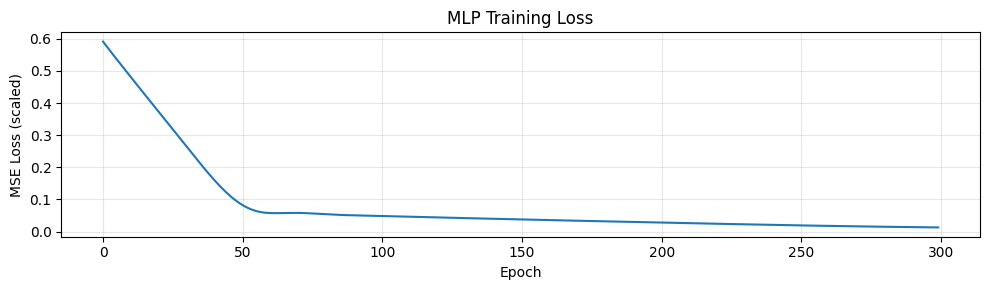

In [ ]:
# ── SOLUTION: Training loop ─────────────────────────────────────────────────
mlp    = MLPForecaster(input_size=N_LAGS, hidden_size=32)
opt    = torch.optim.Adam(mlp.parameters(), lr=1e-3)
loss_fn= nn.MSELoss()

EPOCHS = 300
losses = []

for epoch in range(EPOCHS):
    mlp.train()
    opt.zero_grad()
    pred  = mlp(X_train_t)          # SOLUTION
    loss  = loss_fn(pred, y_train_t) # SOLUTION
    loss.backward()
    opt.step()
    losses.append(loss.item())

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(losses)
ax.set_title('MLP Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (scaled)')
plt.tight_layout()
plt.show()

In [ ]:
# ── SOLUTION: Evaluate MLP ──────────────────────────────────────────────────
mlp.eval()
with torch.no_grad():
    mlp_preds_s = mlp(X_test_t).numpy()                     # scaled predictions

# Inverse-transform to the original (log-diff) scale
mlp_preds = scaler_y.inverse_transform(mlp_preds_s.reshape(-1, 1)).ravel()  # SOLUTION

results['MLP'] = compute_metrics(y_test, mlp_preds, 'MLP')

MLP                             RMSE=0.04958   MAE=0.04013
